In [ ]:
## We load libraries and set up the generator and discriminator code here for the
## DC-GAN
## The code here is directly referenced from the open source repository
## https://github.com/csinva/gan-vae-pretrained-pytorch

from __future__ import print_function
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import torchvision
import torch.nn as nn
from torchvision.utils import save_image
from torch.autograd import Variable
import matplotlib.pyplot as plt
import pylab
import numpy as np
%load_ext autoreload
%autoreload 2

torch.manual_seed(0)

class Generator(nn.Module):
    def __init__(self, ngpu, nc=3, nz=100, ngf=64):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(     nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2,     ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(    ngf,      nc, kernel_size=1, stride=1, padding=0, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output


class Discriminator(nn.Module):
    def __init__(self, ngpu, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 2, 2, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)

        return output.view(-1, 1).squeeze(1)

In [ ]:
## the commands below are for cloning from the reference repository where we
## obtained the DCGAN model and pretrained weights
## and installing the necessary packages
## no need to run this if you already have the reference repository locally or
## have already installed the python pingouin package
!ls
!git clone https://github.com/csinva/gan-vae-pretrained-pytorch.git
!pip install pingouin

sample_data
Cloning into 'gan-vae-pretrained-pytorch'...
remote: Enumerating objects: 187, done.
remote: Total 187 (delta 0), reused 0 (delta 0), pack-reused 187 (from 1)
Receiving objects: 100% (187/187), 88.11 MiB | 21.90 MiB/s, done.
Resolving deltas: 100% (71/71), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 3.6 MB/s eta 0:00:00


In [ ]:
num_gpu = 0

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()

# load weights
D.load_state_dict(torch.load('gan-vae-pretrained-pytorch/cifar10_dcgan/weights/netD_epoch_199.pth',map_location=torch.device('cpu')))
G.load_state_dict(torch.load('gan-vae-pretrained-pytorch/cifar10_dcgan/weights/netG_epoch_199.pth',map_location=torch.device('cpu')))
if torch.cuda.is_available():
    D = D.cuda()
    G = G.cuda()

<ipython-input-3-95234ae027b3>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  D.load_state_dict(torch.load('gan-vae-pretrained-pytorch/cifar10_dcgan/weights/netD_epoch_19

In [ ]:
## Generate synthetic images
batch_size = 1000
latent_size = 100

fixed_noise = torch.randn(batch_size, latent_size, 1, 1)
if torch.cuda.is_available():
    fixed_noise = fixed_noise.cuda()
fake_images = G(fixed_noise)

fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 3, 32, 32)
fake_images_np = fake_images_np.transpose((0, 2, 3, 1))


In [ ]:
## Obtain real images
transform = transforms.Compose(
    [transforms.ToTensor()])

# Load the CIFAR-10 training dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000,
                                          shuffle=True, num_workers=2)

real_images, _ = next(iter(testloader))
real_images_np = real_images.cpu().detach().numpy()
real_images_np = real_images_np.reshape(real_images_np.shape[0], 3, 32, 32)
real_images_np = real_images_np.transpose((0, 2, 3, 1))

100%|██████████| 170M/170M [00:11<00:00, 14.7MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


In [ ]:
## Set up inception embeddings
inception_model = torchvision.models.inception_v3(pretrained=True)
inception_model.eval()  # Set to evaluation mode

# Function to compute inception embeddings
def compute_inception_embeddings(images):
    """Computes inception embeddings for a batch of images."""

    # Preprocess images for Inception v3
    transform = transforms.Compose([
        transforms.Resize(299),  # Inception v3 input size
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    preprocessed_images = torch.stack([transform(Image.fromarray((image * 255).astype(np.uint8))) for image in images])

    with torch.no_grad(): # Important for inference
        embeddings = inception_model(preprocessed_images)

    return embeddings

from scipy.linalg import sqrtm as sqrtmat
def frechet_distance_normal(features1, features2):
    """Computes the Fréchet distance between two normal distributions.

    Args:
        mean1: Mean vector of the first normal distribution.
        cov1: Covariance matrix of the first normal distribution.
        mean2: Mean vector of the second normal distribution.
        cov2: Covariance matrix of the second normal distribution.

    Returns:
        The Fréchet distance between the two normal distributions.
    """

    mu1 = np.mean(features1, axis=0)
    mu2 = np.mean(features2, axis=0)
    sigma1 = np.cov(features1, rowvar=False)
    sigma2 = np.cov(features2, rowvar=False)

    diff = mu1 - mu2
    covmean= sqrtmat(np.matmul(sigma1, sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = np.sqrt(np.sum(diff**2) + np.trace(sigma1 + sigma2 - 2 * covmean))
    return fid

def estimate_characteristic_function(features, t):
    """Estimates the characteristic function at a given point t.

    Args:
        features: A NumPy array of shape (num_samples, num_dimensions) representing the data.
        t: A scalar or a NumPy array of shape (num_dimensions,) representing the point at which to evaluate the characteristic function.

    Returns:
        A NumPy array of shape (num_dimensions,) containing the estimated characteristic function values at each feature dimension.
    """

    num_samples, num_dimensions = features.shape
    characteristic_function_values = np.zeros(num_dimensions, dtype = np.complex_)

    for j in range(num_dimensions):
        characteristic_function_values[j] = np.mean(np.exp(1j * features[:, j]* t))

    return characteristic_function_values

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:01<00:00, 74.9MB/s]


In [ ]:
## The function for the mardia test below is directly referenced from the open
## source repository https://github.com/quillan86/mvn-python/
## which is in turn a translation into Python of original functions in the MVN
## package from R

## Note that the Mardia test function contains skewness statistics as well in addition
## to the Kurtosis test that we use.
## The skewness statistic is not used in our study, since the implementation in
## the python function is flawed/not appropriate for our scenario

import scipy.stats as stats
from typing import Tuple

## function below from https://github.com/quillan86/mvn-python/


def mardia_test(data: np.ndarray, cov: bool = True) -> Tuple[float, float, float, float]:
    """
    https://rdrr.io/cran/MVN/src/R/mvn.R
    https://stats.stackexchange.com/questions/317147/how-to-get-a-single-p-value-from-the-two-p-values-of-a-mardias-multinormality-t
    Mardia's multivariate skewness and kurtosis.
    Calculates the Mardia's multivariate skewness and kurtosis coefficients
    as well as their corresponding statistical test. For large sample size
    the multivariate skewness is asymptotically distributed as a Chi-square
    random variable; here it is corrected for small sample size. However,
    both uncorrected and corrected skewness statistic are presented. Likewise,
    the multivariate kurtosis it is distributed as a unit-normal.

     Syntax: function [Mskekur] = Mskekur(X,c,alpha)

     Inputs:
          X - multivariate data matrix [Size of matrix must be n(data)-by-p(variables)].
          cov - boolean to whether to normalize the covariance matrix by n (c=1[default]) or by n-1 (c~=1)

     Outputs:
          - skewness test statistic
          - kurtosis test statistic
          - significance value for skewness
          - significance value for kurtosis
    """
    n, p = data.shape

    # correct for small sample size
    small: bool = True if n < 20 else False

    if cov:
        S = ((n - 1)/n) * np.cov(data.T)
    else:
        S = np.cov(data.T)

    # calculate mean
    data_mean = data.mean(axis=0)
    # inverse - check if singular matrix
    try:
        iS = np.linalg.inv(S)
    except Exception as e:
        # print for now
        print(e)
        return 0.0, 0.0, 0.0, 0.0
    # squared-Mahalanobis' distances matrix
    D: np.ndarray = (data - data_mean) @ iS @ (data - data_mean).T
    # multivariate skewness coefficient
    g1p: float = np.sum(D**3)/n**2
    # multivariate kurtosis coefficient
    g2p: float = np.trace(D**2)/n
    # small sample correction
    k: float = ((p + 1)*(n + 1)*(n + 3))/(n*(((n + 1)*(p + 1)) - 6))
    # degrees of freedom
    df: float = (p * (p + 1) * (p + 2))/6

    if small:
        # skewness test statistic corrected for small sample: it approximates to a chi-square distribution
        g_skew = (n * g1p * k)/6
    else:
        # skewness test statistic:it approximates to a chi-square distribution
        g_skew = (n * g1p)/6

    # significance value associated to the skewness corrected for small sample
    p_skew: float = 1.0 - stats.chi2.cdf(g_skew, df)

    # kurtosis test statistic: it approximates to a unit-normal distribution
    g_kurt = (g2p - (p*(p + 2)))/(np.sqrt((8 * p * (p + 2))/n))
    # significance value associated to the kurtosis
    p_kurt: float = 2 * (1.0 - stats.norm.cdf(np.abs(g_kurt)))

    return g_skew, g_kurt, p_skew, p_kurt



In [ ]:
# Assuming 'fake_images_np' from the previous code
fake_embeddings = compute_inception_embeddings(fake_images_np)
real_embeddings = compute_inception_embeddings(real_images_np)

In [ ]:
import pingouin as pg
print(pg.multivariate_normality(real_embeddings, alpha=.05))
print(pg.multivariate_normality(fake_embeddings, alpha=.05))


HZResults(hz=4000, pval=0.0, normal=False)
HZResults(hz=4000, pval=0.0, normal=False)


In [ ]:
print(mardia_test(real_embeddings.numpy()))
print(mardia_test(fake_embeddings.numpy()))

(40836488.40693457, -1725.4783900972377, 1.0, 0.0)
(-94426651241.48979, -10408.917520144556, 1.0, 0.0)


In [ ]:
## Compute the FID
mu_fake = torch.mean(fake_embeddings, dim=0)
sigma_fake = torch.cov(fake_embeddings.T)
mu_real = torch.mean(real_embeddings, dim=0)
sigma_real = torch.cov(real_embeddings.T)

diff = mu_real.numpy() - mu_fake.numpy()
covmean= sqrtmat(np.matmul(sigma_fake.numpy(), sigma_real.numpy()))

if np.iscomplexobj(covmean):
    covmean = covmean.real
fid = np.sqrt(np.sum(diff**2) + np.trace(sigma_real.numpy() + sigma_fake.numpy() - 2 * covmean))
print(fid)
print(fid/1000)


0.02555817413330078


In [ ]:
## Compute the ECS
t = 1

characteristic_fake = estimate_characteristic_function(fake_embeddings.numpy(), t)
characteristic_real = estimate_characteristic_function(real_embeddings.numpy(), t)
difference = characteristic_fake - characteristic_real
norms = np.abs(difference)
average_norm = np.mean(norms)/t
print(average_norm)

t = 0.5
characteristic_fake = estimate_characteristic_function(fake_embeddings.numpy(), t)
characteristic_real = estimate_characteristic_function(real_embeddings.numpy(), t)
difference = characteristic_fake - characteristic_real
norms = np.abs(difference)
average_norm = np.mean(norms)/t
print(average_norm)

0.28454458263096066
0.4003187605160969


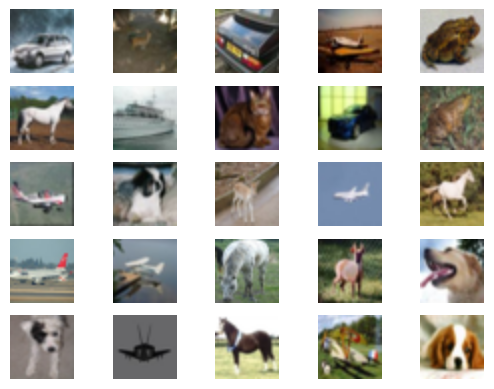

In [ ]:
## plot real and synthetic images in panel
np.random.seed(1)

R, C = 5, 5
for i in range(25):
    plt.subplot(R, C, i + 1)
    plt.axis('off')
    plt.imshow(np.random.permutation(fake_images_np)[i], interpolation='bilinear')

plt.savefig("test1_cifar.png", bbox_inches='tight')

R, C = 5, 5
for i in range(25):
    plt.subplot(R, C, i + 1)
    plt.axis('off')
    plt.imshow(np.random.permutation(real_images_np)[i], interpolation='bilinear')

plt.savefig("test2_cifar.png", bbox_inches='tight')